# Part 2: Market Basket Analysis and Product Recommendation

## 1. Data Understanding

- **What a transaction means:**  
A transaction simply means one complete purchase made by a customer. It can include one or multiple products, and it is identified using the `TransactionID`.

- **What an item means:**  
An item refers to a product bought in a transaction. Each product has its own `ProductID` and `ProductName`.

- **What each row represents:**  
Each row in the dataset shows one product purchased in a particular transaction along with the quantity bought.

- **Why Market Basket Analysis is useful:**  
Market Basket Analysis helps the business understand which products customers usually buy together. This can help in improving product placement, creating combo offers, and increasing overall sales.

- **How product association helps in cross-selling and upselling:**  
If customers often buy products like coffee and sugar together, the business can recommend sugar when someone buys coffee. In the same way, businesses can also create bundles or premium offers to encourage customers to buy more products together.

## 2. Data Cleaning
Let's load the data, investigate it, and clean anomalies before conducting our analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# 1. Load the dataset
df = pd.read_csv('part_2_market_basket_analysis.csv')

print("Original Shape:", df.shape)

# 2. Cleaning Steps:

# Step A: Handle Missing Product Names (Transactions without valid products are useless for basket analysis)
df.dropna(subset=['ProductName'], inplace=True)

# Step B: Handle Invalid Quantities (Remove cancelled transactions or return items where quantity <= 0)
df = df[df['Quantity'] > 0]

# Step C: Drop duplicate transaction-product records (e.g., if the same item was scanned twice by mistake)
df.drop_duplicates(inplace=True)

print("Cleaned Shape:", df.shape)
df.head()

Original Shape: (4311, 7)
Cleaned Shape: (4215, 7)


,TransactionID,CustomerID,TransactionDate,ProductID,ProductName,Quantity,UnitPrice
0,TX200001,C10416,2025-06-04,MB009,Granola Bar,2,841
1,TX200002,C10782,2025-04-03,MB028,Notebook,1,743
2,TX200002,C10782,2025-04-03,MB030,Sticky Notes,1,568
3,TX200003,C10836,2025-03-23,MB001,Coffee Beans,1,775
4,TX200003,C10836,2025-03-23,MB002,Instant Coffee,2,249


### Cleaning Explanation

- **Missing Product Names:**  
Rows with missing product names were removed because products without proper names cannot be used for association analysis.

- **Invalid Quantities:**  
Rows where the quantity was less than or equal to zero were excluded since they usually represent cancelled orders or returned products. Market Basket Analysis only works with products that were actually purchased together.

- **Duplicate Records:**  
Duplicate rows were removed to avoid incorrect results. Keeping duplicates could increase product counts artificially and affect the accuracy of support and association values.

## 3. Transaction Basket Preparation
We need to transform our list of items into a matrix where rows = Transactions and columns = Products. The values will be 1 (purchased) or 0 (not purchased).

In [3]:
# Group by TransactionID and ProductName, sum the quantities, pivot to columns, and fill NAs with 0
basket = (df.groupby(['TransactionID', 'ProductName'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('TransactionID'))

# Convert any quantity >= 1 to 1 (True), and quantity 0 to 0 (False)
def encode_units(x):
    if x <= 0:
        return False
    if x >= 1:
        return True

basket_sets = basket.map(encode_units)

print("Basket Matrix Shape:", basket_sets.shape)
basket_sets.head()

Basket Matrix Shape: (1799, 30)


ProductName,Almond Pack,Baby Diapers,Baby Lotion,Baby Wipes,Black Tea,Body Wash,Bread Loaf,Butter,Chocolate Spread,Coffee Beans,...,Nachos,Notebook,Oats Pack,Peanut Butter,Pen Pack,Potato Chips,Protein Bar,Salsa Dip,Shampoo,Sticky Notes
TransactionID,,,,,,,,,,,,,,,,,,,,,
TX200001,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TX200002,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
TX200003,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
TX200004,False,True,True,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TX200005,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Basket Format Explanation

The dataset was converted into a basket format where each `TransactionID` represents one row and each `ProductName` becomes a separate column.  

If a product was purchased in a transaction, its value is marked as `1` (or `True`), and if it was not purchased, the value is marked as `0` (or `False`).  

The `encode_units` function helps convert product quantities into this simple binary format. This format is important because association rule algorithms work by checking whether products are present together in a transaction, not by the exact quantity purchased.

## 4. Frequent Itemset Generation
We'll use `fpgrowth` to generate frequent itemsets. It is generally faster than Apriori for large datasets.

In [4]:
# Testing min_support values to observe differences:
# Support 0.05 (5%)
freq_05 = fpgrowth(basket_sets, min_support=0.05, use_colnames=True)
print(f"Itemsets with 5% support: {len(freq_05)}")

# Support 0.01 (1%)
freq_01 = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)
print(f"Itemsets with 1% support: {len(freq_01)}")

# We will proceed with a min_support of 1% (0.01)
frequent_itemsets = freq_01
frequent_itemsets.sort_values(by='support', ascending=False).head(10)

Itemsets with 5% support: 41
Itemsets with 1% support: 77


,support,itemsets
0,0.143969,frozenset({Granola Bar})
27,0.120067,frozenset({Chocolate Spread})
3,0.100056,frozenset({Coffee Beans})
21,0.100056,frozenset({French Press})
19,0.098388,frozenset({Butter})
16,0.097276,frozenset({Salsa Dip})
4,0.096165,frozenset({Instant Coffee})
20,0.094497,frozenset({Bread Loaf})
11,0.083936,frozenset({Fabric Softener})
63,0.081156,"frozenset({Chocolate Spread, Butter})"


### **Support Threshold Explanation:**
*   If `support` is too high (e.g., 10%), we only see the absolute most common individual items and miss the combinations.
*   If `support` is too low (e.g., 0.001%), we generate thousands of coincidental pairs that lack statistical meaning.
*   **Choice:** We chose `0.01` (1%) because it strikes a strong balance, giving us enough multi-item subsets to generate meaningful association rules without overwhelming the system with noise.

## 5. Association Rule Generation

In [5]:
# Generate Association Rules using Lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Sticky Notes}),frozenset({Pen Pack}),0.065592,0.070039,0.038911,0.593220,8.469868,1.0,0.034317,2.286154,0.943843,0.402299,0.562584,0.574388
1,frozenset({Pen Pack}),frozenset({Sticky Notes}),0.070039,0.065592,0.038911,0.555556,8.469868,1.0,0.034317,2.102418,0.948356,0.402299,0.524357,0.574388
2,frozenset({Sticky Notes}),frozenset({Notebook}),0.065592,0.062813,0.036131,0.550847,8.769687,1.0,0.032011,2.086568,0.948163,0.391566,0.520744,0.563034
3,frozenset({Notebook}),frozenset({Sticky Notes}),0.062813,0.065592,0.036131,0.575221,8.769687,1.0,0.032011,2.199752,0.945351,0.391566,0.545403,0.563034
4,frozenset({Notebook}),frozenset({Pen Pack}),0.062813,0.070039,0.040578,0.646018,9.223697,1.0,0.036179,2.627140,0.951340,0.439759,0.619358,0.612691


### Metric Explanations

- **Support:**  
Support shows how often a combination of products appears in all transactions. Higher support means the products are commonly purchased together by customers.

- **Confidence:**  
Confidence tells us how likely a customer is to buy one product when they have already purchased another product. It helps measure the strength of the association between products.

- **Lift:**  
Lift compares the actual relationship between two products with what would happen if the purchases were completely random.

  - **Why Lift > 1 is important:**  
  A lift value greater than 1 means the products are positively related and are more likely to be bought together. If the lift is equal to 1, it means there is no real relationship between the products.

## 6. Rule Filtering and Interpretation
We will filter the rules to find the most strongly correlated, high-confidence associations.

In [8]:
filtered_rules = rules[(rules['lift'] >= 1.2) & (rules['confidence'] >= 0.2)]
filtered_rules = filtered_rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print(f"Total Highly Actionable Rules: {len(filtered_rules)}")
top_10_rules = filtered_rules.head(10)
top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Total Highly Actionable Rules: 154


,antecedents,consequents,support,confidence,lift
67,"frozenset({Baby Diapers, Baby Lotion})",frozenset({Baby Wipes}),0.026126,0.921569,11.355493
70,frozenset({Baby Wipes}),"frozenset({Baby Diapers, Baby Lotion})",0.026126,0.321918,11.355493
151,"frozenset({Almond Pack, Electrolyte Drink})",frozenset({Protein Bar}),0.021123,0.633333,10.648287
154,frozenset({Protein Bar}),"frozenset({Almond Pack, Electrolyte Drink})",0.021123,0.355140,10.648287
152,"frozenset({Electrolyte Drink, Protein Bar})",frozenset({Almond Pack}),0.021123,0.593750,10.370449
153,frozenset({Almond Pack}),"frozenset({Electrolyte Drink, Protein Bar})",0.021123,0.368932,10.370449
150,"frozenset({Almond Pack, Protein Bar})",frozenset({Electrolyte Drink}),0.021123,0.666667,10.163842
155,frozenset({Electrolyte Drink}),"frozenset({Almond Pack, Protein Bar})",0.021123,0.322034,10.163842
62,frozenset({Baby Wipes}),frozenset({Baby Lotion}),0.046137,0.568493,10.125932
63,frozenset({Baby Lotion}),frozenset({Baby Wipes}),0.046137,0.821782,10.125932


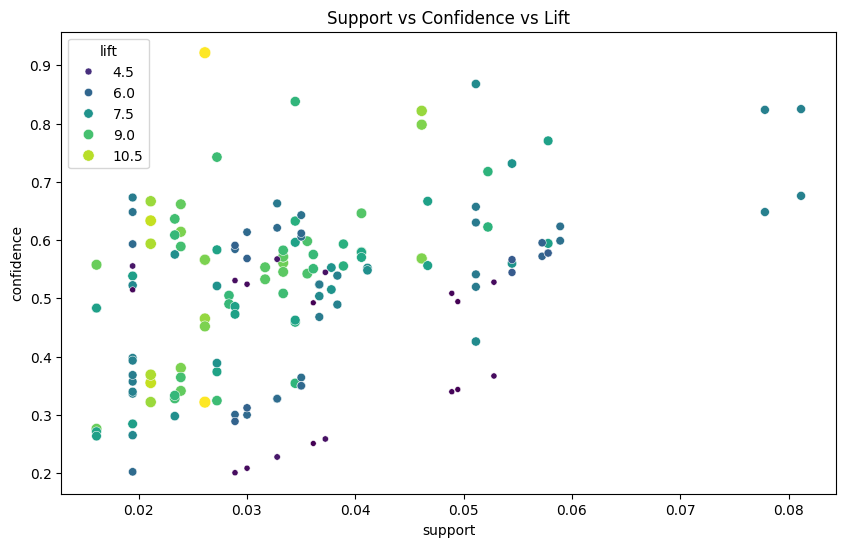

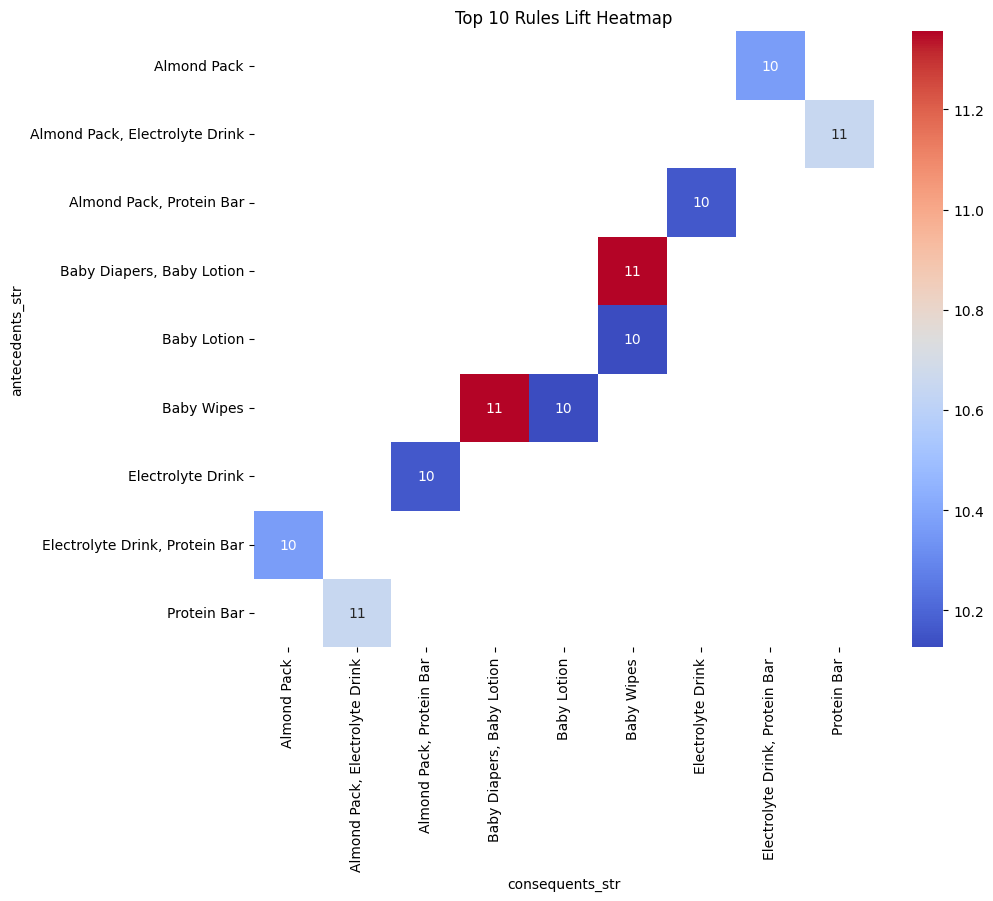

In [7]:
# Generate Visualizations for the rules
# Scatter plot for Support vs Confidence
plt.figure(figsize=(10,6))
sns.scatterplot(x='support', y='confidence', size='lift', data=filtered_rules, hue='lift', palette='viridis')
plt.title('Support vs Confidence vs Lift')
plt.show()

# Heatmap of top 10 rules for support
# Convert frozensets to strings for plotting
top_10_plot = top_10_rules.copy()
top_10_plot['antecedents_str'] = top_10_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
top_10_plot['consequents_str'] = top_10_plot['consequents'].apply(lambda x: ', '.join(list(x)))

pivot = top_10_plot.pivot(index='antecedents_str', columns='consequents_str', values='lift')
plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Top 10 Rules Lift Heatmap')
plt.show()

### Interpretation of the Top 10 Association Rules

#### 1. Baby Diapers → Baby Wipes
- **Support (0.026):** About 2.6% of all transactions included both Baby Diapers and Baby Wipes.
- **Confidence (0.922):** Most customers who bought diapers also purchased wipes.
- **Lift (11.35):** This is a very strong relationship between the two products.
- **Business Meaning:** These products are closely connected, so the business can place them together in stores or recommend wipes whenever customers buy diapers.

---

#### 2. Baby Wipes → Baby Diapers
- **Support (0.026):** Both products appeared together in 2.6% of transactions.
- **Confidence (0.322):** Around one-third of customers buying wipes also purchased diapers.
- **Lift (11.35):** Shows a strong association between the products.
- **Business Meaning:** Wipes may also be used for other purposes, but there is still a strong connection between wipes and diapers.

---

#### 3. Almond Pack → Protein Bar
- **Support (0.021):** Around 2.1% of transactions contained both products.
- **Confidence (0.633):** Many customers who bought almonds also purchased protein bars.
- **Lift (10.64):** Indicates a strong buying pattern.
- **Business Meaning:** Customers interested in healthy snacks often buy these products together.

---

#### 4. Protein Bar → Almond Pack
- **Support / Confidence / Lift:** Similar strong relationship as above.
- **Business Meaning:** Customers buying protein bars can also be recommended almond packs as a related product.

---

#### 5. Electrolyte Drink → Almond Pack
- **Metrics:** These products show high confidence and lift values.
- **Business Meaning:** This suggests a fitness or gym-related shopping pattern where customers prefer health-focused items together.

---

#### 6–8. Electrolyte Drink, Protein Bar, and Almond Pack Combinations
- **Business Meaning:** These products are commonly purchased together, making them suitable for combo offers or bundle recommendations.

---

#### 9. Baby Wipes → Baby Lotion
- **Support (0.046):** Around 4.6% of transactions included both products.
- **Confidence (0.568):** More than half of the customers buying wipes also bought lotion.
- **Lift (10.12):** Strong product relationship.
- **Business Meaning:** These are complementary baby care products and can be promoted together.

---

#### 10. Baby Lotion → Baby Wipes
- **Support (0.046):** Both products appeared together in many transactions.
- **Confidence (0.822):** Most lotion buyers also purchased wipes.
- **Lift (10.12):** Strong association between the products.
- **Business Meaning:** Recommending wipes along with baby lotion can help improve cross-selling opportunities.

## 7. Business Recommendations

Based on the association rules generated from the analysis, the following recommendations can help improve sales and customer experience:

1. **Products that can be bundled together**
   - Products with high confidence and lift values are frequently purchased together. These products can be combined into combo packs or special offers to encourage customers to buy more items in a single purchase.

2. **Products that should be placed near each other**
   - Products that show strong associations can be placed close to each other in stores or grouped together on e-commerce websites. This makes shopping more convenient and increases the chances of additional purchases.

3. **Products suitable for cross-selling**
   - If customers commonly buy one product along with another, the related product can be recommended during checkout or on the product page using suggestions like “Customers also bought.”

4. **Products useful for promotional campaigns**
   - Products with strong associations can be included in promotional offers. Giving discounts on one product may increase the sales of related products that customers usually buy together.

5. **Rules that should not be focused on**
   - Some products may show high support or confidence simply because they are commonly purchased by almost everyone. If the lift value is close to 1, it means there is no strong relationship between the products, so such rules may not be very useful for marketing decisions.

6. **How these insights help the business**
   - These insights can improve product recommendations, make shopping easier for customers, and help businesses create better marketing strategies. Overall, it can increase customer satisfaction and improve sales performance.